<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_11_desicion_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 11: Árboles de desición


#Algoritmo CART (classification and regresion tree)

Se busca entrenar un modelo para categorizar la información encontrando la frontera de desición, permite tener una mejor interpretabilidad que las redes neuronales dado que se puede tener una represetancion grafica del proceso de desiscion secuencial.

- ref https://www.youtube.com/watch?v=kqaLlte6P6o&ab_channel=CodificandoBits
- Hand on Machine leargning 




Dado un conjunto de caracteristicas se establece una condición que realiza 
una particion binaria de los datos a clasificar repitiendo hasta encontrar 
particiones lo más homogenea posible.




In [1]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pylab as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
import graphviz
#from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree


Text(0, 0.5, '$X_2$')

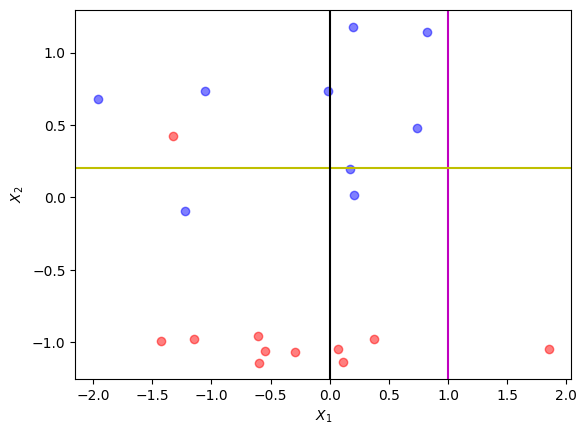

In [2]:
X0, y0 = make_classification(n_samples=20,
    n_features=2, n_redundant=0, n_informative=1, random_state=42, 
    n_clusters_per_class=1)

x=np.arange(-2, 3,1)
x_,y_ = np.meshgrid(x,x)

fig, ax = plt.subplots()
ax.plot(X0[:,0][y0==0],X0[:,1][y0==0],"ro", alpha=0.5)
ax.plot(X0[:,0][y0==1],X0[:,1][y0==1],"bo", alpha=0.5)
#ax.plot(x_,y_,"k.")

ax.axvline(x = 1, color = 'm', label="x1<=1")
ax.axhline(y = 0.2, color = 'y', label="x2<0.2")
ax.axvline(x = 0.0, color = 'k', label="x2<0.2")
#plt.legend(loc=3)
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")


- Gini index


$G = 1 - (PC_1)^2 - (PC_2)^2$

$PC_1$: Probablidad categoria 1 

$PC_2$: Probablidad categoria 2 

Si :

- $G=0$ nodos puros, datos que pertenecen a una sola categoría

- Gini > 0 son nodos con impurezas, con mas de una categoría


La partición purpura  y amarilla del gráfico anterior representan nodos puros.

Mientras que la linea negra define:

- 7 puntos son de color azul.

- 6 puntos de color rojo.

$G = 1 - (7/13)^{2} - (6/13)^{2}$

mientrás que la ponderacion viene dada por:

$m = (7/20+7/20)=7/10$



No:

$G=1-(3/7)^{2}-(4/7)^{2}$
m = (3/20+4/20)


La funcion de coste, asocida al nodo padre:

$J(k, t_k) = \frac{m_{left}}{m} G_{left} + \frac{m_{right}}{m} G_{right} $



# Algoritmo
1. Calcular todos los posibles condiciones. 
2. Calcular los indices de Gini.
3. Encontrar la funcion de coste 
4. Escoger la menor funcion de coste 
5. Repetir.



1. Importar iris dataset 


In [3]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


2. Generar una intuición respecto a iris dataset. Ver laboratorio anterior.
3. Dividir el *dataset* empleanto el metodo train_test_split de sklearn

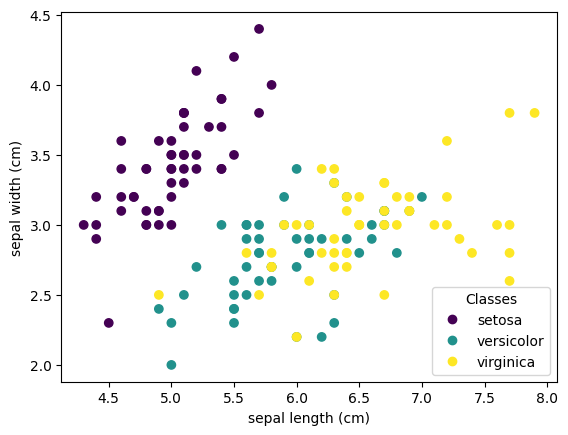

In [4]:
# Extraido del sitio web de sklearn:

_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

<p style="font-size:18px">El dataset contiene 4 columnas numéricas (float) que describen propiedades físicas de 3 especies de flores: Setosa, Versicolor, Virginica. Las columnas describen el <b>ANCHO Y LARGO</b> de los sépalos y los pétalos de cada especie.</p>

In [5]:
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.33, random_state=42)

4. Dentro de sklearn, aplicar el algoritmo DecisionTreeClassifier.

In [6]:
# Extraido de la propia documentacion de DecisionTreeClassifier de sklearn:
from sklearn.model_selection import cross_val_score

clf = DecisionTreeClassifier(random_state=0) # Todos los parametros por defecto, excepto el random_state para reproducibilidad

iris = load_iris()

cross_val_score(clf, iris.data, iris.target, cv=10)

array([1.        , 0.93333333, 1.        , 0.93333333, 0.93333333,
       0.86666667, 0.93333333, 1.        , 1.        , 1.        ])

5. Para el clasificador analice el gráfico de desición:

```

https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html

  fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
  graph=tree.plot_tree(clf,class_names = iris.target_names,\
                feature_names = iris.feature_names,\
                impurity=False, filled=True,rounded=True )

```

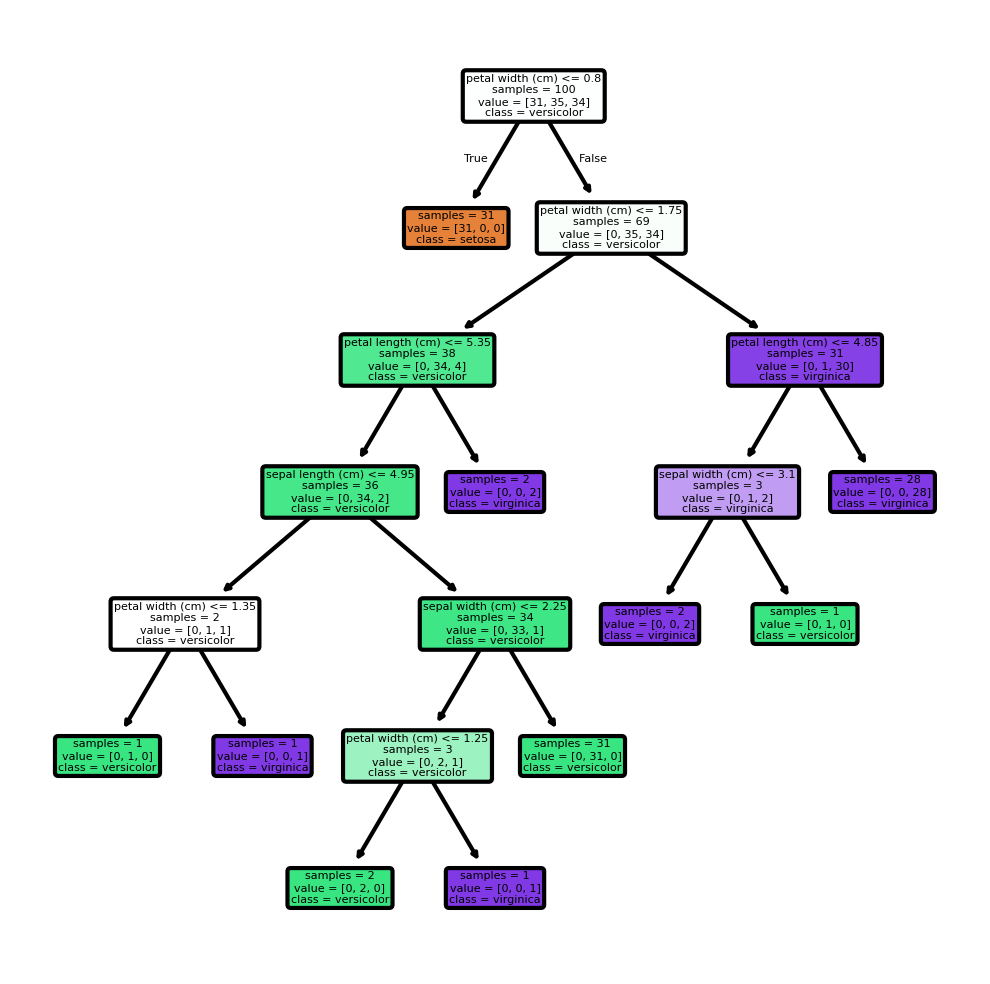

In [7]:
clf.fit(X_train, y_train)
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
graph=tree.plot_tree(clf,class_names = iris.target_names,\
            feature_names = iris.feature_names,\
            impurity=False, filled=True,rounded=True )

6. Características importantes.

```
clf.feature_importances_
caract = iris.data.shape[1]
plt.barh(range(caract), clf.feature_importances_)
plt.yticks(np.arange(caract),iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.show()
```

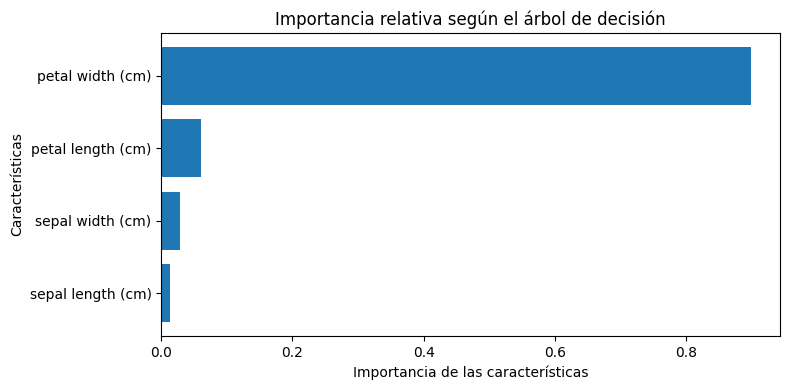

In [8]:
caract = iris.data.shape[1]
plt.figure(figsize=(8, 4))
plt.barh(range(caract), clf.feature_importances_, align='center')
plt.yticks(np.arange(caract), iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.title('Importancia relativa según el árbol de decisión')
plt.tight_layout()
plt.show()

### Interpretación: Importancia de características

El atributo `feature_importances_` devuelve la **reducción media ponderada de impureza Gini** que aporta cada característica en todos los nodos del árbol donde fue usada. Sus valores siempre suman exactamente **1.0**.

**¿Qué esperamos ver?**
- `petal length (cm)` y `petal width (cm)` concentran la mayor importancia: los pétalos discriminan mucho mejor entre *Versicolor* y *Virginica*.
- `sepal length (cm)` y `sepal width (cm)` aportan muy poco, porque las clases se superponen en esas dimensiones (como se vio en el punto 2).

**Precaución:** cuando una sola característica absorbe casi toda la importancia (> 0.9), puede ser correcto si esa variable es genuinamente discriminativa, pero en otros datasets puede ser señal de sobreajuste o *data leakage*.

/tmp/ipykernel_266970/1961867149.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx_class, 0], X[idx_class, 1], c=color,
/tmp/ipykernel_266970/1961867149.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx_class, 0], X[idx_class, 1], c=color,
/tmp/ipykernel_266970/1961867149.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx_class, 0], X[idx_class, 1], c=color,
/tmp/ipykernel_266970/1961867149.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx_class, 0], X[idx_class, 1], c=color,
/tmp/ipykernel_266970/1961867149.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx_class, 0], X[idx_class, 1], c=color,
/tmp/ipykernel_266970/1961867149.py:44: UserWarning: No data for 

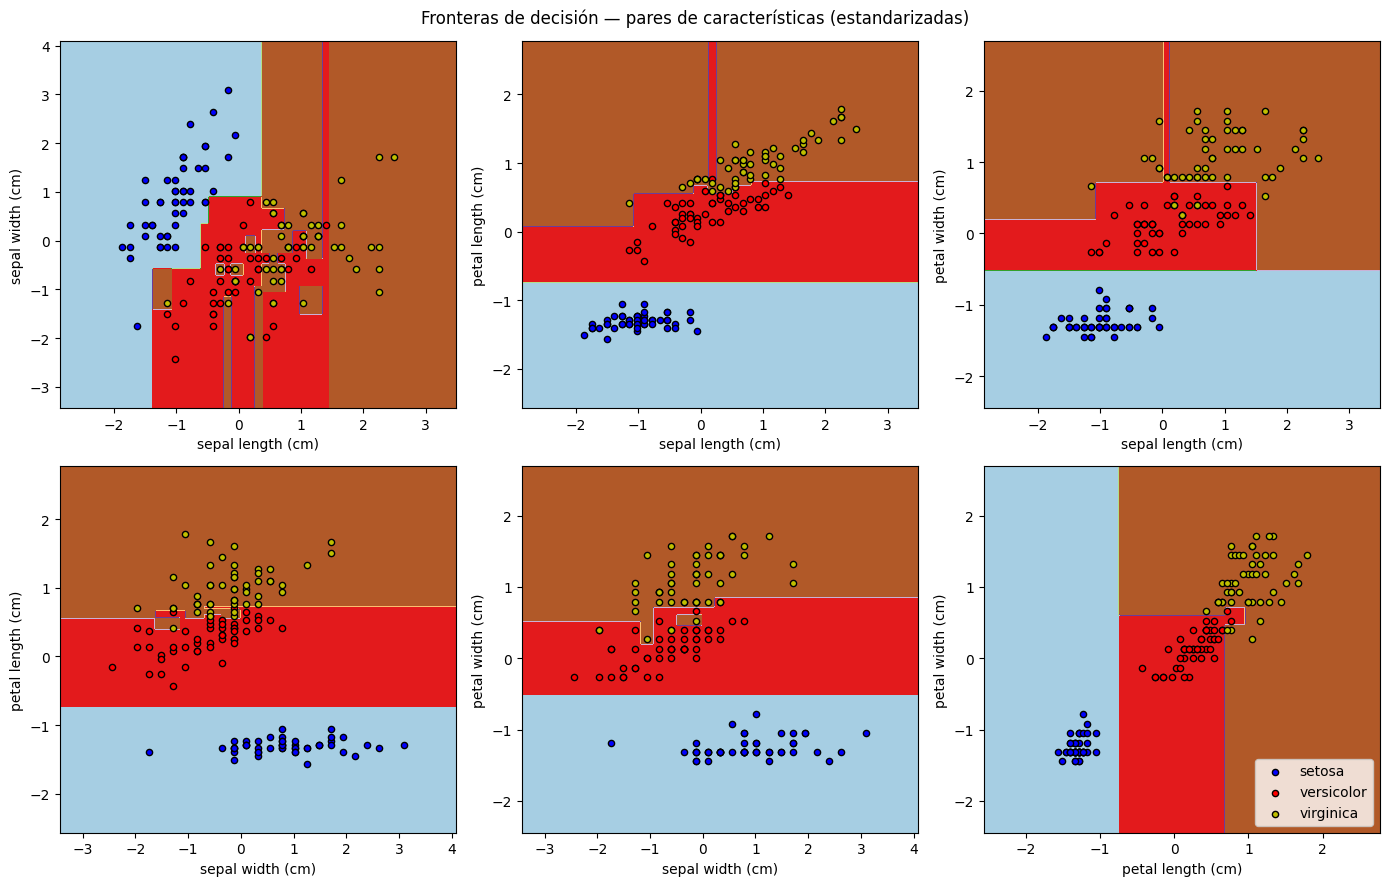

In [9]:
n_classes = 3
plot_colors = "bry"
plot_step = 0.02

iris = load_iris()

plt.figure(figsize=(14, 9))

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                 [1, 2], [1, 3], [2, 3]]):
    X = iris.data[:, pair]
    y = iris.target

    idx = np.arange(X.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]

    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X = (X - mean) / std

    # clf_pair evita sobreescribir el clf global entrenado en el punto 5
    clf_pair = DecisionTreeClassifier().fit(X, y)

    plt.subplot(2, 3, pairidx + 1)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    Z = clf_pair.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")

    for i, color in zip(range(n_classes), plot_colors):
        idx_class = np.where(y == i)
        plt.scatter(X[idx_class, 0], X[idx_class, 1], c=color,
                    label=iris.target_names[i], cmap=plt.cm.Paired,
                    edgecolors='k', s=20)

    plt.axis("tight")

plt.suptitle("Fronteras de decisión — pares de características (estandarizadas)")
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0))
plt.tight_layout()
plt.show()

7. Fronteras de decisión

/tmp/ipykernel_266970/1482062056.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
/tmp/ipykernel_266970/1482062056.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
/tmp/ipykernel_266970/1482062056.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
/tmp/ipykernel_266970/1482062056.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
/tmp/ipykernel_266970/1482062056.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.ta

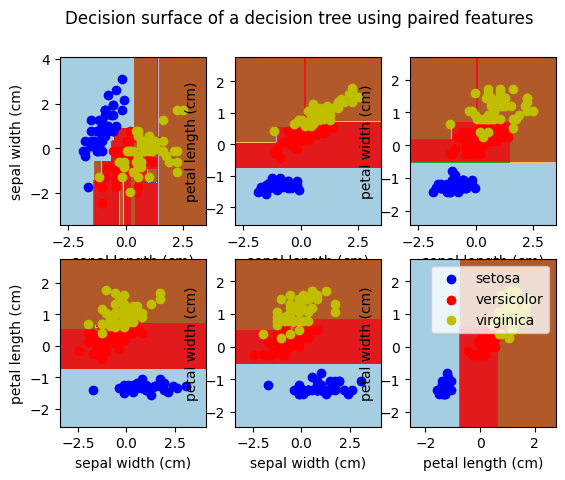

In [10]:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# Parameters
n_classes = 3
plot_colors = "bry"
plot_step = 0.02

# Load data
iris = load_iris()

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target

    # Shuffle
    idx = np.arange(X.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]

    # Standardize
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X = (X - mean) / std

    # Train
    clf = DecisionTreeClassifier().fit(X, y)

    # Plot the decision boundary
    plt.subplot(2, 3, pairidx + 1)
  
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
                    cmap=plt.cm.Paired)

    plt.axis("tight")

plt.suptitle("Decision surface of a decision tree using paired features")
plt.legend()
plt.show()

### Interpretación: Fronteras de decisión por pares

Cada subplot entrena un árbol sin especificar max_depth, usando solo 2 características estandarizadas, lo que permite visualizar en 2D cómo el modelo divide el espacio de decisión.

COsas que noto:
- Pares con pétalos (`petal length` / `petal width`): fronteras simples y limpias. <b>Setosa</b> queda completamente aislada, y la separación *Versicolor*/*Virginica* es casi lineal.
- Pares con sépalos (`sepal length` / `sepal width`): fronteras más irregulares y fracturadas, el árbol necesita muchos más cortes para separar clases que se solapan, señal de <b>sobreajuste</</b> potencial.

Patrón: 

- Fronteras rectas = árbol poco profundo, bien generalizado. 
- Fronteras muy irregulares = árbol profundo que memoriza ruido del entrenamiento. Controlar `max_depth` es la principal herramienta de regularización en Decision Trees.